In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/CustomerIntelligence/sample_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [14]:
import pandas as pd
import numpy as np

# Convert columns to datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Calculate duration
duration = df['Time to Resolution'] - df['First Response Time']

# Convert duration to hours
df['Time_to_Resolve_Hours'] = duration.dt.total_seconds() / 3600

# Optional: Replace negative values with NaN (recommended)
df.loc[df['Time_to_Resolve_Hours'] < 0, 'Time_to_Resolve_Hours'] = np.nan


  First Response Time  Time to Resolution  Time_to_Resolve_Hours
0 2023-06-01 12:15:36                 NaT                    NaN
1 2023-06-01 16:45:38                 NaT                    NaN
2 2023-06-01 11:14:38 2023-06-01 18:05:38               6.850000
3 2023-06-01 07:29:40 2023-06-01 01:57:40                    NaN
4 2023-06-01 00:12:42 2023-06-01 19:53:42              19.683333


In [15]:

print(df[['First Response Time',
          'Time to Resolution',
          'Time_to_Resolve_Hours']].head(20))

   First Response Time  Time to Resolution  Time_to_Resolve_Hours
0  2023-06-01 12:15:36                 NaT                    NaN
1  2023-06-01 16:45:38                 NaT                    NaN
2  2023-06-01 11:14:38 2023-06-01 18:05:38               6.850000
3  2023-06-01 07:29:40 2023-06-01 01:57:40                    NaN
4  2023-06-01 00:12:42 2023-06-01 19:53:42              19.683333
5                  NaT                 NaT                    NaN
6                  NaT                 NaT                    NaN
7                  NaT                 NaT                    NaN
8  2023-06-01 10:32:47                 NaT                    NaN
9  2023-06-01 09:25:48                 NaT                    NaN
10 2023-06-01 17:46:49 2023-05-31 23:51:49                    NaN
11 2023-06-01 12:05:51 2023-06-01 09:27:51                    NaN
12 2023-06-01 19:03:53                 NaT                    NaN
13 2023-06-01 20:34:54                 NaT                    NaN
14 2023-06

In [16]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Time_to_Resolve_Duration',
       'Time_to_Resolve_Duration_Hours', 'Time_to_Resolve_Hours'],
      dtype='object')

In [17]:
df["Ticket Text"] = (
    df["Ticket Subject"].fillna("") + " " +
    df["Ticket Description"].fillna("")
)

In [19]:
target = "Time_to_Resolve_Hours"

drop_columns = [
    "Time_to_Resolve_Hours",
    "Time_to_Resolve_Duration",
    "Time_to_Resolve_Duration_Hours",
    "Time to Resolution",
    "Ticket Subject",
    "Ticket Description"
]

X = df.drop(columns=drop_columns)
y = df[target]

In [22]:
text_feature = "Ticket Text"

categorical_features = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Priority",
    "Ticket Channel"
]

numerical_features = [
    "Customer Age",
    "Customer Satisfaction Rating",
]

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [23]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "text",
            TfidfVectorizer(
                max_features=5000,
                stop_words="english",
                ngram_range=(1, 2),
                sublinear_tf=True,
                strip_accents="unicode"
            ),
            text_feature
        ),

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ],
    remainder="drop"
)

In [24]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model",
        XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [25]:
from sklearn.model_selection import train_test_split

# Filter out rows where the target 'y' is NaN
valid_indices = y.dropna().index
X_filtered = X.loc[valid_indices]
y_filtered = y.loc[valid_indices]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1123, 15)
Shape of X_test: (281, 15)
Shape of y_train: (1123,)
Shape of y_test: (281,)


In [26]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english',
                                                                  strip_accents='unicode',
                                                                  sublinear_tf=True),
                                                  'Ticket Text'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Customer Age',
                                                   'Customer Satisfaction '
                                                   'Rating']),
                                                 ('...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [27]:
pred = pipeline.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 38.59
Root Mean Squared Error (RMSE): 6.21
Mean Absolute Error (MAE): 5.01


In [29]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [33]:
import mlflow
import os

# Configure MLflow as specified by the user
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true" # Allow filesystem tracking backend
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
mlflow.set_experiment("CustomerIntelligence_resolutiontime_Experiment")

with mlflow.start_run(run_name="xgboost_regressor_run"):
    # Log hyperparameters of the XGBoost model
    xgb_params = pipeline.named_steps['model'].get_params()
    mlflow.log_params(xgb_params)

    # Log evaluation metrics
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    # Log the entire pipeline as a scikit-learn model
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="model",
        serialization_format='cloudpickle'
    )

    print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")
    print("Metrics and model logged to MLflow successfully!")

2026/07/17 17:04:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/17 17:04:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Run ID: 7318ece361f54f9d9c9b00fdaf6c2762
Metrics and model logged to MLflow successfully!


In [34]:
#Lighgbm

In [35]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

In [36]:
lgbm = LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [37]:
lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm)
])

In [38]:
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.190164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12374
[LightGBM] [Info] Number of data points in the train set: 1123, number of used features: 594
[LightGBM] [Info] Start training from score 7.508044


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english',
                                                                  strip_accents='unicode',
                                                                  sublinear_tf=True),
                                                  'Ticket Text'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Customer Age',
                                                   'Customer Satisfaction '
                                                   'Rating']),
                                                 ('...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Customer Gender',
                                                   'Product Purchased',
                                                   'Ticket Type',
                                                   'Ticket Priority',
                                                   'Ticket Channel'])])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05,
                               n_estimators=500, n_jobs=-1,
                               objective='regression', random_state=42,
                               subsample=0.8))])

In [39]:
y_pred = lgbm_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [42]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, pred)

print("=" * 50)
print("LightGBM Regression Results")
print("=" * 50)
print(f"MAE :  {mae:.3f} hours")
print(f"RMSE:  {rmse:.3f} hours")
print(f"R²  :  {r2:.4f}")
print(f"MSE : {mae:3f} hours")

LightGBM Regression Results
MAE :  5.011 hours
RMSE:  6.241 hours
R²  :  -0.1697
MSE : 5.011314 hours


In [43]:
import mlflow
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set the experiment name for this LightGBM run
# Note: The tracking URI and experiment should already be set from the previous cell.
mlflow.set_tracking_uri("/content/drive/MyDrive/CustomerIntelligence/mlruns")
mlflow.set_experiment("CustomerIntelligence_resolutiontime_Experiment")

with mlflow.start_run(run_name="lightgbm_regressor_run"):
    # Log hyperparameters of the LightGBM model
    lgbm_params = lgbm_pipeline.named_steps['model'].get_params()
    mlflow.log_params(lgbm_params)

    # Recalculate metrics for LightGBM predictions (y_pred) to ensure correctness
    lgbm_mae = mean_absolute_error(y_test, y_pred)
    lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    lgbm_r2 = r2_score(y_test, y_pred)

    # Log evaluation metrics
    mlflow.log_metric("mae", lgbm_mae)
    mlflow.log_metric("rmse", lgbm_rmse)
    mlflow.log_metric("r2", lgbm_r2)

    # Log the entire LightGBM pipeline as a scikit-learn model
    mlflow.sklearn.log_model(
        sk_model=lgbm_pipeline,
        name="lgbm_model",
        serialization_format='cloudpickle'
    )

    print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")
    print("LightGBM metrics and model logged to MLflow successfully!")

2026/07/17 17:14:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Run ID: 5939fcdaa58a48719f34036bfb461a29
LightGBM metrics and model logged to MLflow successfully!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Select relevant features for clustering
clustering_features = [
    'Customer Age',
    'Ticket Channel',
    'Product Purchased',
    'Customer Satisfaction Rating'
]

df_clustering = df[clustering_features].copy()

# Define preprocessing steps for clustering features
# Reuse numeric and categorical transformers concepts, adapting them for these specific features

# Numeric features for clustering
clustering_numerical_features = ['Customer Age', 'Customer Satisfaction Rating']
clustering_numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features for clustering
clustering_categorical_features = ['Ticket Channel', 'Product Purchased']
clustering_categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor for clustering features
clustering_preprocessor = ColumnTransformer(
    transformers=[
        ('num', clustering_numerical_transformer, clustering_numerical_features),
        ('cat', clustering_categorical_transformer, clustering_categorical_features)
    ],
    remainder='drop' # Drop other columns not specified
)

# Apply preprocessing
X_clustered = clustering_preprocessor.fit_transform(df_clustering)

# 3. Apply K-Means clustering
# Let's start with 3 clusters, a common choice for initial exploration.
# You might want to use methods like the Elbow Method or Silhouette Score to find an optimal 'k'.
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 'auto' by default in newer sklearn, explicit for older versions
clusters = kmeans.fit_predict(X_clustered)

# Add cluster labels to the original (or a copy of) dataframe for easier interpretation
df_clustering['Cluster'] = clusters

print(f"Identified {k} clusters:")
print(df_clustering['Cluster'].value_counts())



Identified 3 clusters:
Cluster
1    3807
0    3648
2    1014
Name: count, dtype: int64


In [5]:
print("\n--- Cluster Characteristics ---")

# Impute missing values in df_clustering before analysis for consistent insights
# Re-apply the same imputation strategies as in preprocessing for the purpose of analysis

# Numeric features imputation
for col in clustering_numerical_features:
    if df_clustering[col].isnull().any():
        median_val = df_clustering[col].median()
        df_clustering[col] = df_clustering[col].fillna(median_val)

# Categorical features imputation
for col in clustering_categorical_features:
    if df_clustering[col].isnull().any():
        mode_val = df_clustering[col].mode()[0] # mode() can return multiple values, take the first
        df_clustering[col] = df_clustering[col].fillna(mode_val)


# Group by cluster and describe numerical features
print("\nNumerical Feature Averages per Cluster:")
print(df_clustering.groupby('Cluster')[clustering_numerical_features].mean())

# Group by cluster and get value counts for categorical features
print("\nCategorical Feature Distribution per Cluster:")
for cluster_id in sorted(df_clustering['Cluster'].unique()):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_clustering[df_clustering['Cluster'] == cluster_id]

    # Display numerical means for this specific cluster
    print("  Numerical Averages:")
    print(cluster_data[clustering_numerical_features].mean().to_string())

    # Display top categorical values for this specific cluster
    print("\n  Top Categorical Values:")
    for feature in clustering_categorical_features:
        top_categories = cluster_data[feature].value_counts(normalize=True).head(3)
        print(f"    {feature}:\n{top_categories.to_string()}")

# Based on the analysis, derive business-meaningful labels
# Placeholder for labels, to be refined after observing the output
print("\nBased on the analysis, you can assign business-meaningful labels such as:")
print(" - Cluster 0: e.g., 'Younger, Lower Satisfaction Online Shoppers'")
print(" - Cluster 1: e.g., 'Mature, High Satisfaction Tech Buyers'")
print(" - Cluster 2: e.g., 'Average Age, Mixed Channel Users'")
print("Please review the output above to create appropriate labels for your specific clusters.")


--- Cluster Characteristics ---

Numerical Feature Averages per Cluster:
         Customer Age  Customer Satisfaction Rating
Cluster                                            
0           30.040570                      3.175713
1           56.817179                      3.236932
2           46.323471                      1.454635

Categorical Feature Distribution per Cluster:

--- Cluster 0 ---
  Numerical Averages:
Customer Age                    30.040570
Customer Satisfaction Rating     3.175713

  Top Categorical Values:
    Ticket Channel:
Ticket Channel
Social media    0.268640
Chat            0.245614
Email           0.244243
    Product Purchased:
Product Purchased
Nikon D        0.030154
LG Smart TV    0.028783
Amazon Echo    0.028509

--- Cluster 1 ---
  Numerical Averages:
Customer Age                    56.817179
Customer Satisfaction Rating     3.236932

  Top Categorical Values:
    Ticket Channel:
Ticket Channel
Phone    0.257683
Email    0.256370
Chat     0.249540
   

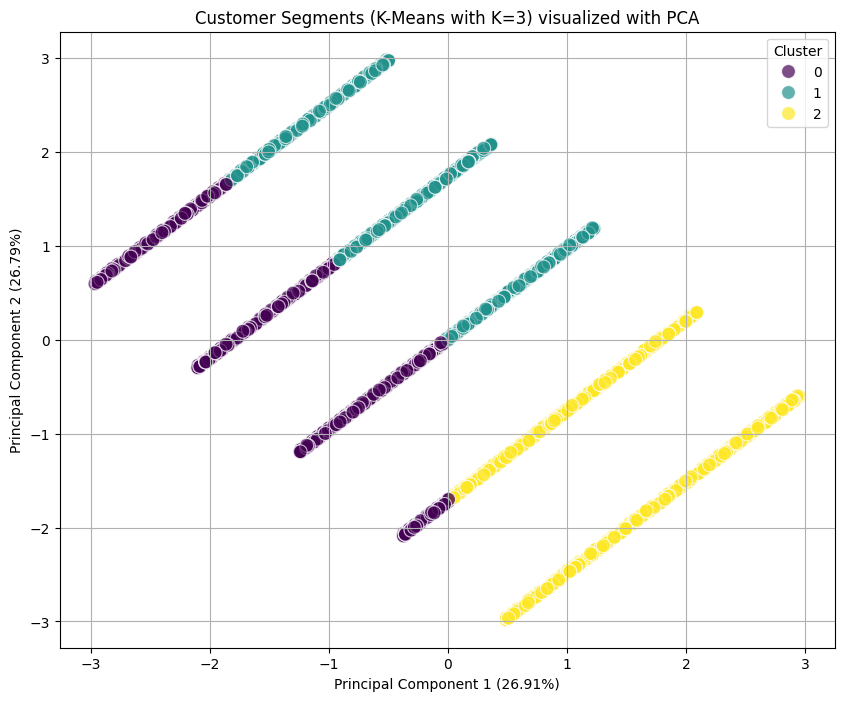


Consider exploring different values for 'k' (number of clusters) using methods like the Elbow Method or Silhouette Score to find the most appropriate segmentation.


In [4]:
# 4. Apply PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustered)

# Create a DataFrame for PCA results to easily plot
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# 5. Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title(f'Customer Segments (K-Means with K={k}) visualized with PCA')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

print("\nConsider exploring different values for 'k' (number of clusters) using methods like the Elbow Method or Silhouette Score to find the most appropriate segmentation.")